In [35]:
#### Use the unstable kernel for the analysis of CCEW
import xarray as xr
import numpy as np
import healpy as hp
import intake
import datetime
import easygems.healpix as egh

In [36]:
####only for the first time
#!pip install /home/sw5261/pywk99

In [37]:
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [38]:
from pywk99.spectrum import get_power_spectrum, get_background_spectrum
from pywk99.timeseries import remove_linear_trend, remove_seasonal_cycle
from pywk99.spectrum import plot_spectrum, plot_spectrum_peaks
from pywk99.waves import plot_dispersion_relations
from pywk99.filter import get_wave_filter_window, get_box_filter_window
from pywk99.filter import get_mjo_window, get_tropical_depression_window
from pywk99.filter import filter_variable

In [39]:
from pywk99.grid.healpix import dataarray_healpix_to_equatorial_latlon

In [40]:
import sys
sys.path.append("/home/sw5261/")

In [41]:
import dask
from dask.distributed import Client
dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})
client = Client()

/home/sw5261/.conda/envs/easy25/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35673 instead
  warnings.warn(
2025-05-15 15:05:02,364 - distributed.scheduler - WARNING - Failed to format dashboard link, unknown value: 'JUPYTERHUB_SERVICE_PREFIX'


In [42]:
def genDispersionCurves(nWaveType=6, nPlanetaryWave=50, rlat=0, Ahe=[50, 25, 12]):
    """
    Function to derive the shallow water dispersion curves. Closely follows NCL version.

    input:
        nWaveType : integer, number of wave types to do
        nPlanetaryWave: integer
        rlat: latitude in radians (just one latitude, usually 0.0)
        Ahe: [50.,25.,12.] equivalent depths
              ==> defines parameter: nEquivDepth ; integer, number of equivalent depths to do == len(Ahe)

    returns: tuple of size 2
        Afreq: Frequency, shape is (nWaveType, nEquivDepth, nPlanetaryWave)
        Apzwn: Zonal savenumber, shape is (nWaveType, nEquivDepth, nPlanetaryWave)
        
    notes:
        The outputs contain both symmetric and antisymmetric waves. In the case of 
        nWaveType == 6:
        0,1,2 are (ASYMMETRIC) "MRG", "IG", "EIG" (mixed rossby gravity, inertial gravity, equatorial inertial gravity)
        3,4,5 are (SYMMETRIC) "Kelvin", "ER", "IG" (Kelvin, equatorial rossby, inertial gravity)
    """
    nEquivDepth = len(Ahe) # this was an input originally, but I don't know why.
    pi    = np.pi
    radius = 6.37122e06    # [m]   average radius of earth
    g     = 9.80665        # [m/s] gravity at 45 deg lat used by the WMO
    omega = 7.292e-05      # [1/s] earth's angular vel
    # U     = 0.0   # NOT USED, so Commented
    # Un    = 0.0   # since Un = U*T/L  # NOT USED, so Commented
    ll    = 2.*pi*radius*np.cos(np.abs(rlat))
    Beta  = 2.*omega*np.cos(np.abs(rlat))/radius
    fillval = 1e20
    
    # NOTE: original code used a variable called del,
    #       I just replace that with `dell` because `del` is a python keyword.

    # Initialize the output arrays
    Afreq = np.empty((nWaveType, nEquivDepth, nPlanetaryWave))
    Apzwn = np.empty((nWaveType, nEquivDepth, nPlanetaryWave))

    for ww in range(1, nWaveType+1):
        for ed, he in enumerate(Ahe):
            # this loops through the specified equivalent depths
            # ed provides index to fill in output array, while
            # he is the current equivalent depth
            # T = 1./np.sqrt(Beta)*(g*he)**(0.25) This is close to pre-factor of the dispersion relation, but is not used.
            c = np.sqrt(g * he)  # phase speed   
            L = np.sqrt(c/Beta)  # was: (g*he)**(0.25)/np.sqrt(Beta), this is Rossby radius of deformation        

            for wn in range(1, nPlanetaryWave+1):
                s  = -20.*(wn-1)*2./(nPlanetaryWave-1) + 20.
                k  = 2.0 * pi * s / ll
                kn = k * L 

                # Anti-symmetric curves  
                if (ww == 1):       # MRG wave
                    if (k < 0):
                        dell  = np.sqrt(1.0 + (4.0 * Beta)/(k**2 * c))
                        deif = k * c * (0.5 - 0.5 * dell)
                    
                    if (k == 0):
                        deif = np.sqrt(c * Beta)
                    
                    if (k > 0):
                        deif = fillval
                    
                
                if (ww == 2):       # n=0 IG wave
                    if (k < 0):
                        deif = fillval
                    
                    if (k == 0):
                        deif = np.sqrt( c * Beta)
                    
                    if (k > 0):
                        dell  = np.sqrt(1.+(4.0*Beta)/(k**2 * c))
                        deif = k * c * (0.5 + 0.5 * dell)
                    
                
                if (ww == 3):       # n=2 IG wave
                    n=2.
                    dell  = (Beta*c)
                    deif = np.sqrt((2.*n+1.)*dell + (g*he) * k**2)
                    # do some corrections to the above calculated frequency.......
                    for i in range(1,5+1):
                        deif = np.sqrt((2.*n+1.)*dell + (g*he) * k**2 + g*he*Beta*k/deif)
                    
    
                # symmetric curves
                if (ww == 4):       # n=1 ER wave
                    n=1.
                    if (k < 0.0):
                        dell  = (Beta/c)*(2.*n+1.)
                        deif = -Beta*k/(k**2 + dell)
                    else:
                        deif = fillval
                    
                if (ww == 5):       # Kelvin wave
                    deif = k*c

                if (ww == 6):       # n=1 IG wave
                    n=1.
                    dell  = (Beta*c)
                    deif = np.sqrt((2. * n+1.) * dell + (g*he)*k**2)
                    # do some corrections to the above calculated frequency
                    for i in range(1,5+1):
                        deif = np.sqrt((2.*n+1.)*dell + (g*he)*k**2 + g*he*Beta*k/deif)
                
                eif  = deif  # + k*U since  U=0.0
                P    = 2.*pi/(eif*24.*60.*60.)  #  => PERIOD
                # dps  = deif/k  # Does not seem to be used.
                # R    = L #<-- this seemed unnecessary, I just changed R to L in Rdeg
                # Rdeg = (180.*L)/(pi*6.37e6) # And it doesn't get used.
            
                Apzwn[ww-1,ed-1,wn-1] = s
                if (deif != fillval):
                    # P = 2.*pi/(eif*24.*60.*60.) # not sure why we would re-calculate now
                    Afreq[ww-1,ed-1,wn-1] = 1./P
                else:
                    Afreq[ww-1,ed-1,wn-1] = fillval
    return  Afreq, Apzwn

In [43]:
def get_wk99_spectrums(variable, grid_type="latlon", grid_dict=None):
    new_variable = remove_seasonal_cycle(variable)
    new_variable = remove_linear_trend(new_variable)
    window_length = "92D"
    overlap_length = "60D"
    data_frequency = "12h"
    symmetric_spectrum = get_power_spectrum(
        new_variable,
        "symmetric",
        data_frequency,
        window_length,
        overlap_length,
        grid_type=grid_type,
        grid_dict=grid_dict,
    )
    asymmetric_spectrum = get_power_spectrum(
        new_variable,
        "asymmetric",
        data_frequency,
        window_length,
        overlap_length,
        grid_type=grid_type,
        grid_dict=grid_dict,
    )
    background_spectrum = get_background_spectrum(
        symmetric_spectrum, asymmetric_spectrum
    )
    return symmetric_spectrum, asymmetric_spectrum, background_spectrum

# Analysis

## Open datasets

Please note the following:
- ICON's data is currently obtained from zarr files. This should be changed so that the data comes from the intake catalog.
- A linear interpolation of the model data is made to account for missing simulated days in June. This should be unnecessary when using the intake catalog.
- For both observations and simulations, and to allow direct comparison, the wave-frequency spectra is computed on the same healpix zoom 5 grid. This means that NOAA's OLR is first interpolated to healpix. 

Downloading NOAA OLR data and its interpolation to a healpix grid is done as follows:
```bash
wget https://downloads.psl.noaa.gov/Datasets/interp_OLR/olr.2xdaily.1979-2022.nc
cdo remapbil,hpz5 olr.2xdaily.1979-2022.nc olr.hpz5.2xdaily.1979-2022.nc
```


In [61]:
time_slice = slice("2020-01-01", "2020-12-31")

In [152]:
%%time
## XSHIELD
catfn='/home/tmerlis/hackathon/xsh24_scream_main.yaml'

combo_cat = intake.open_catalog(catfn)

# 'coarse' is an online coarse-graining of 8 neighboring grid cells ~25km

print (list(combo_cat))
zoom_select = 7
ds = combo_cat.xsh24_coarse(zoom=zoom_select).to_dask()
# attach coordinates; otherwise can't use lat and lon and selecting regions or taking a zonal mean won't work
ds_xshield = ds.pipe(egh.attach_coords)

['xsh24_coarse', 'xsh24_native', 'xsh21_coarse', 'scream2D_hrly', 'scream_ne120', 'scream_lnd']
CPU times: user 140 ms, sys: 11.3 ms, total: 151 ms
Wall time: 188 ms


/home/sw5261/.conda/envs/easy25/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [153]:
# Using one year of model data
xshield_olr = ds_xshield.rlut.compute()
xshield_olr = xshield_olr.dropna("time")
xshield_olr = xshield_olr.resample(time="12h", closed="right", label="right", offset="6h").mean()
#xshield_olr = xshield_olr.interpolate_na("time") # interpolate missing dates linearly (some days missing in June)
xshield_olr = xshield_olr.sel(time=time_slice)

new_time = np.array([np.datetime64(t.isoformat()) for t in xshield_olr.time.values])
# Replace the time coordinate
xshield_olr = xshield_olr.assign_coords(time=new_time)

In [74]:
# Using one year of model data
xshield_pr = ds_xshield.pr.compute()
xshield_pr = xshield_pr.dropna("time")
xshield_pr = xshield_pr.resample(time="12h", closed="right", label="right", offset="6h").mean()
#xshield_pr = xshield_pr.interpolate_na("time") # interpolate missing dates linearly (some days missing in June)
xshield_pr = xshield_pr.sel(time=time_slice)

new_time = np.array([np.datetime64(t.isoformat()) for t in xshield_pr.time.values])
# Replace the time coordinate
xshield_pr = xshield_pr.assign_coords(time=new_time)

In [155]:
## XSHIELD
catfn='/home/tmerlis/hackathon/xsh24_scream_main.yaml'

combo_cat = intake.open_catalog(catfn)

# 'coarse' is an online coarse-graining of 8 neighboring grid cells ~25km

print (list(combo_cat))
ds_coarse = combo_cat.xsh24_coarse(zoom=7).to_dask()
# attach coordinates; otherwise can't use lat and lon and selecting regions or taking a zonal mean won't work
ds_coarse_xshield = ds_coarse.pipe(egh.attach_coords)

['xsh24_coarse', 'xsh24_native', 'xsh21_coarse', 'scream2D_hrly', 'scream_ne120', 'scream_lnd']


/home/sw5261/.conda/envs/easy25/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [344]:
%%time
# Using one year of model data
xshield_u850 = ds_coarse_xshield.ua.sel(plev=250, method='nearest').compute()
print(xshield_u850.shape)
xshield_u850 = xshield_u850.dropna("time")
print(xshield_u850.shape)
xshield_u850 = xshield_u850.resample(time="12h", closed="right", label="right", offset="6h").mean()
#xshield_u850 = xshield_u850.interpolate_na("time") # interpolate missing dates linearly (some days missing in June)
xshield_u850 = xshield_u850.sel(time=time_slice)

new_time = np.array([np.datetime64(t.isoformat()) for t in xshield_u850.time.values])
# Replace the time coordinate
xshield_u850 = xshield_u850.assign_coords(time=new_time)#.compute()

(3560, 196608)
(3560, 196608)
CPU times: user 38.8 s, sys: 3.09 s, total: 41.8 s
Wall time: 45.2 s


In [345]:
%%time
# Using one year of model data
xshield_v850 = ds_coarse_xshield.va.sel(plev=250, method='nearest').compute()
print(xshield_v850.shape)
xshield_v850 = xshield_v850.dropna("time")
print(xshield_v850.shape)
xshield_v850 = xshield_v850.resample(time="12h", closed="right", label="right", offset="6h").mean()
#xshield_v850 = xshield_v850.interpolate_na("time") # interpolate missing dates linearly (some days missing in June)
xshield_v850 = xshield_v850.sel(time=time_slice)

new_time = np.array([np.datetime64(t.isoformat()) for t in xshield_v850.time.values])
# Replace the time coordinate
xshield_v850 = xshield_v850.assign_coords(time=new_time)#.compute()

(3560, 196608)
(3560, 196608)
CPU times: user 38.8 s, sys: 3.05 s, total: 41.8 s
Wall time: 45.8 s


In [346]:
%%time
# Using one year of model data
xshield_gz = ds_coarse_xshield.zg.sel(plev=250, method='nearest').compute()
print(xshield_gz.shape)
xshield_gz = xshield_gz.dropna("time")
print(xshield_gz.shape)
xshield_gz = xshield_gz.resample(time="12h", closed="right", label="right", offset="6h").mean()
#xshield_gz = xshield_gz.interpolate_na("time") # interpolate missing dates linearly (some days missing in June)
xshield_gz = xshield_gz.sel(time=time_slice)

new_time = np.array([np.datetime64(t.isoformat()) for t in xshield_gz.time.values])
# Replace the time coordinate
xshield_gz = xshield_gz.assign_coords(time=new_time)#.compute()

(3560, 196608)
(3560, 196608)
CPU times: user 38.6 s, sys: 3.09 s, total: 41.7 s
Wall time: 44.3 s


In [157]:
# Using one year of model data
xshield_u250 = ds_coarse_xshield.ua.sel(plev=250, method='nearest').compute()
print(xshield_u250.shape)
print(np.count_nonzero(~np.isnan(xshield_u250)))
xshield_u250 = xshield_u250.dropna("time")
print(xshield_u250.shape)
xshield_u250 = xshield_u250.resample(time="12h", closed="right", label="right", offset="6h").mean()
#xshield_u250 = xshield_u250.interpolate_na("time") # interpolate missing dates linearly (some days missing in June)
xshield_u250 = xshield_u250.sel(time=time_slice)

new_time = np.array([np.datetime64(t.isoformat()) for t in xshield_u250.time.values])
# Replace the time coordinate
xshield_u250 = xshield_u250.assign_coords(time=new_time)

(3560, 196608)
699924480
(3560, 196608)


In [75]:
# Noaa OLR resampled to healpix grid, one year of data
zoom = 5
time_slice = slice("2020-01-01", "2020-12-31")
noaa_olr = xr.open_dataset("/home/aw2143/hackathon/noaa_olr_healpix/new/olr.hpz5_v2.2xdaily.1979-2022.nc", chunks={'time': 100})
noaa_olr_full = noaa_olr.olr
noaa_olr_full = noaa_olr_full.rename({'cells':'cell'})
noaa_olr = noaa_olr_full.sel(time=time_slice)
noaa_olr = noaa_olr.compute()

In [ ]:
# ERA5 
time_slice = slice("2020-01-01", "2020-12-31")
catfn='/home/sw5261/internal.yaml'

combo_cat = intake.open_catalog("https://tcodata.mpimet.mpg.de/internal.yaml")

# 'coarse' is an online coarse-graining of 8 neighboring grid cells ~25km

print (list(combo_cat))
ds_era = combo_cat.HERA5(zoom=7, time="PT1H").to_dask()
# attach coordinates; otherwise can't use lat and lon and selecting regions or taking a zonal mean won't work
ds_era = ds_era.pipe(egh.attach_coords)

In [ ]:
era_u250 = ds_era.u.sel(level=250, method='nearest')#.compute()
print(era_u250.shape)
#print(np.count_nonzero(~np.isnan(era_u250)))
#era_u250 = era_u250.dropna("time")
print(era_u250.shape)
#era_u250 = era_u250.resample(time="12h", closed="right", label="right", offset="6h").mean()
#xshield_u250 = xshield_u250.interpolate_na("time") # interpolate missing dates linearly (some days missing in June)
#era_u250 = era_u250.sel(time=time_slice)

new_time = np.array([np.datetime64(t.isoformat()) for t in era_u250.time.values])
# Replace the time coordinate
#era_u250 = era_u250.assign_coords(time=new_time).compute()

## Compute anomaly

In [66]:
# not using currently
order = zoom_select
nside = hp.order2nside(order)
npix = hp.nside2npix(nside)

hp_lon, hp_lat = hp.pix2ang(nside, np.arange(npix), nest=True, lonlat=True)
hp_lon = (hp_lon + 180) % 360 - 180

extent_tropics = [0, 360, -20, 20]

trop_cells, = np.where(
    (hp_lon > extent_tropics[0]) &
    (hp_lon < extent_tropics[1]) &
    (hp_lat > extent_tropics[2]) &
    (hp_lat < extent_tropics[3]))

trop_filter = lambda da: da.isel(cell=trop_cells)

In [76]:
xshield_olr_daily = xshield_olr.resample(time="24h", closed="right", label="right", offset="12h").mean()

In [77]:
noaa_olr_mean = noaa_olr_full.groupby("time.dayofyear").mean(dim='time')

In [78]:
xshield_olr_anom = xshield_olr_daily.groupby("time.dayofyear") - noaa_olr_mean

## Compute spectra and spectral peaks

In [180]:
# define grid_dict for analysis
grid_dict = dict(nside=ds_xshield.crs.healpix_nside,
                 nest=ds_xshield.crs.healpix_order == "nest",
                 minmax_lat=15)

In [48]:
# define grid_dict for analysis
grid_dict_coarse = dict(nside=ds_coarse_xshield.crs.healpix_nside,
                 nest=ds_coarse_xshield.crs.healpix_order == "nest",
                 minmax_lat=15)

In [80]:
# Compute model spectra
xshield_symmetric, xshield_asymmetric, xshield_background = get_wk99_spectrums(
    xshield_olr, grid_type="healpix", grid_dict=grid_dict
)
xshield_symmetric = xshield_symmetric.sel(wavenumber=slice(-20, 20))
xshield_asymmetric = xshield_asymmetric.sel(wavenumber=slice(-20, 20))
xshield_background = xshield_background.sel(wavenumber=slice(-20, 20))

In [81]:
# Compute model spectra
xshield_pr_symmetric, xshield_pr_asymmetric, xshield_pr_background = get_wk99_spectrums(
    xshield_pr, grid_type="healpix", grid_dict=grid_dict
)
xshield_pr_symmetric = xshield_pr_symmetric.sel(wavenumber=slice(-20, 20))
xshield_pr_asymmetric = xshield_pr_asymmetric.sel(wavenumber=slice(-20, 20))
xshield_pr_background = xshield_pr_background.sel(wavenumber=slice(-20, 20))

In [49]:
%%time
# Compute model spectra
xshield_u850_symmetric, xshield_u850_asymmetric, xshield_u850_background = get_wk99_spectrums(
    xshield_u850, grid_type="healpix", grid_dict=grid_dict_coarse
)
xshield_u850_symmetric = xshield_u850_symmetric.sel(wavenumber=slice(-20, 20))
xshield_u850_asymmetric = xshield_u850_asymmetric.sel(wavenumber=slice(-20, 20))
xshield_u850_background = xshield_u850_background.sel(wavenumber=slice(-20, 20))

CPU times: user 1min 37s, sys: 3.82 s, total: 1min 41s
Wall time: 1min 5s


In [50]:
# Compute model spectra
xshield_u250_symmetric, xshield_u250_asymmetric, xshield_u250_background = get_wk99_spectrums(
    xshield_u250, grid_type="healpix", grid_dict=grid_dict_coarse
)
xshield_u250_symmetric = xshield_u250_symmetric.sel(wavenumber=slice(-20, 20))
xshield_u250_asymmetric = xshield_u250_asymmetric.sel(wavenumber=slice(-20, 20))
xshield_u250_background = xshield_u250_background.sel(wavenumber=slice(-20, 20))

In [82]:
# Observations spectra
noaa_symmetric, noaa_asymmetric, noaa_background = get_wk99_spectrums(
    noaa_olr, grid_type="healpix", grid_dict=grid_dict
)
noaa_symmetric = noaa_symmetric.sel(wavenumber=slice(-20, 20))
noaa_asymmetric = noaa_asymmetric.sel(wavenumber=slice(-20, 20))
noaa_background = noaa_background.sel(wavenumber=slice(-20, 20))

In [167]:
# Difference
diff_symmetric = np.log10(xshield_symmetric) - np.log10(noaa_symmetric)
diff_asymmetric = np.log10(xshield_asymmetric) - np.log10(noaa_asymmetric)
diff_background = np.log10(xshield_background) - np.log10(noaa_background)

In [168]:
# spectral peaks model
xshield_symmetric_peaks = xshield_symmetric / xshield_background
xshield_asymmetric_peaks = xshield_asymmetric / xshield_background

xshield_pr_symmetric_peaks = xshield_pr_symmetric / xshield_pr_background
xshield_pr_asymmetric_peaks = xshield_pr_asymmetric / xshield_pr_background

In [169]:
# spectral peaks observations
noaa_symmetric_peaks = noaa_symmetric / noaa_background
noaa_asymmetric_peaks = noaa_asymmetric / noaa_background

In [51]:
xshield_u850_symmetric_peaks = xshield_u850_symmetric / xshield_u850_background
xshield_u850_asymmetric_peaks = xshield_u850_asymmetric / xshield_u850_background

xshield_u250_symmetric_peaks = xshield_u250_symmetric / xshield_u250_background
xshield_u250_asymmetric_peaks = xshield_u250_asymmetric / xshield_u250_background

## Filter for diferent wave types

In [52]:
# Define filter windows
kelvin_window = get_wave_filter_window(
    "kelvin", k_min=1, k_max=14, w_min=0.075, w_max=0.4, h_min=8, h_max=90
)
rossby_window = get_wave_filter_window(
    "equatorial_rossby",
    k_min=-14,
    k_max=1,
    w_min=0.0,
    w_max=0.4,
    h_min=4,
    h_max=90,
)
mixed_rossby_window = get_wave_filter_window(
    "mixed_rossby_gravity",
    k_min=-12,
    k_max=12,
    w_min=0.075,
    w_max=1,
    h_min=8,
    h_max=90,
)
ig_window = get_wave_filter_window(
    "inertio_gravity",
    k_min=-14,
    k_max=1,
    w_min=0.3,
    w_max=1,
    h_min=8,
    h_max=90,
)
mjo_window = get_mjo_window()
td_window = get_tropical_depression_window()
filters = [
    kelvin_window,
    rossby_window,
    mixed_rossby_window,
    ig_window,
    mjo_window,
    td_window,
]

In [181]:
# Filter fields
filtered_xshield = filter_variable(
    xshield_olr, filters, grid_type="healpix", grid_dict=grid_dict
)
filtered_noaa = filter_variable(
    noaa_olr, filters, grid_type="healpix", grid_dict=grid_dict
)

IndexError: index 67071 is out of bounds for axis 1 with size 12288

# Plots

In [165]:
swfreq,swwn = genDispersionCurves()
# swfreq.shape # -->(6, 3, 50)
swf = np.where(swfreq == 1e20, np.nan, swfreq)
swk = np.where(swwn == 1e20, np.nan, swwn)

Text(0.5, 1.0, 'Asymmetric')

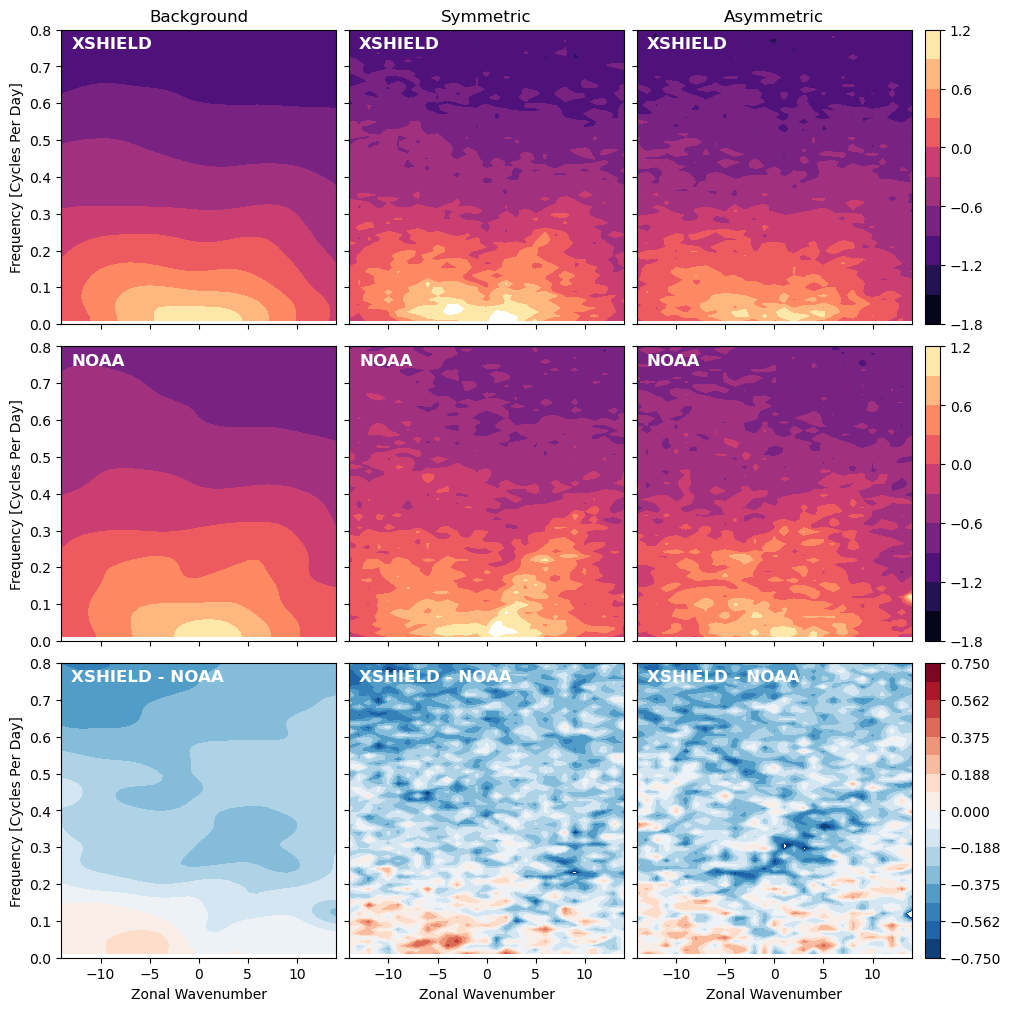

In [170]:
# plot spectra
fig, axs = plt.subplots(3, 3, figsize=(10, 10), constrained_layout=True)

k = xshield_background.wavenumber
w = xshield_background.frequency
spectrum_levels = np.linspace(-1.8, 1.2, 11)
diff_levels = np.linspace(-0.75, 0.75, 17)

axs[0, 0].contourf(
    k,
    w,
    np.log10(xshield_background.values),
    levels=spectrum_levels,
    cmap="magma",
)
axs[0, 0].set_xticklabels([])
axs[0, 0].set_ylabel("Frequency [Cycles Per Day]")
axs[0, 0].annotate(
    "XSHIELD",
    xy=(-13, 0.75),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="w",
)
axs[0, 1].contourf(
    k, w, np.log10(xshield_symmetric.values), levels=spectrum_levels, cmap="magma"
)
axs[0, 1].set_xticklabels([])
axs[0, 1].set_yticklabels([])
axs[0, 1].annotate(
    "XSHIELD",
    xy=(-13, 0.75),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="w",
)
cs = axs[0, 2].contourf(
    k,
    w,
    np.log10(xshield_asymmetric.values),
    levels=spectrum_levels,
    cmap="magma",
)
axs[0, 2].set_xticklabels([])
axs[0, 2].set_yticklabels([])
axs[0, 2].annotate(
    "XSHIELD",
    xy=(-13, 0.75),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="w",
)
fig.colorbar(cs, ax=axs[0, 2])

k = noaa_background.wavenumber
w = noaa_background.frequency
axs[1, 0].contourf(
    k,
    w,
    np.log10(noaa_background.values),
    levels=spectrum_levels,
    cmap="magma",
)
axs[1, 0].set_xticklabels([])
axs[1, 0].set_ylabel("Frequency [Cycles Per Day]")
axs[1, 0].annotate(
    "NOAA",
    xy=(-13, 0.75),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="w",
)
axs[1, 1].contourf(
    k, w, np.log10(noaa_symmetric.values), levels=spectrum_levels, cmap="magma"
)
axs[1, 1].set_xticklabels([])
axs[1, 1].set_yticklabels([])
axs[1, 1].annotate(
    "NOAA",
    xy=(-13, 0.75),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="w",
)
cs = axs[1, 2].contourf(
    k,
    w,
    np.log10(noaa_asymmetric.values),
    levels=spectrum_levels,
    cmap="magma",
)
axs[1, 2].set_xticklabels([])
axs[1, 2].set_yticklabels([])
axs[1, 2].annotate(
    "NOAA",
    xy=(-13, 0.75),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="w",
)
fig.colorbar(cs, ax=axs[1, 2])

axs[2, 0].contourf(
    k, w, diff_background.values, levels=diff_levels, cmap="RdBu_r"
)
axs[2, 0].set_xlabel("Zonal Wavenumber")
axs[2, 0].set_ylabel("Frequency [Cycles Per Day]")
axs[2, 0].annotate(
    "XSHIELD - NOAA",
    xy=(-13, 0.75),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="w",
)
axs[2, 1].contourf(
    k, w, diff_symmetric.values, levels=diff_levels, cmap="RdBu_r"
)
axs[2, 1].set_yticklabels([])
axs[2, 1].set_xlabel("Zonal Wavenumber")
axs[2, 1].annotate(
    "XSHIELD - NOAA",
    xy=(-13, 0.75),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="w",
)
cs = axs[2, 2].contourf(
    k, w, diff_asymmetric.values, levels=diff_levels, cmap="RdBu_r"
)
axs[2, 2].set_yticklabels([])
axs[2, 2].set_xlabel("Zonal Wavenumber")
axs[2, 2].annotate(
    "XSHIELD - NOAA",
    xy=(-13, 0.75),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="w",
)
fig.colorbar(cs, ax=axs[2, 2])

for ax in axs.ravel():
    ax.set_xlim(-14, 14)
    ax.set_ylim(0, 0.8)

axs[0,0].set_title('Background')
axs[0,1].set_title('Symmetric')
axs[0,2].set_title('Asymmetric')

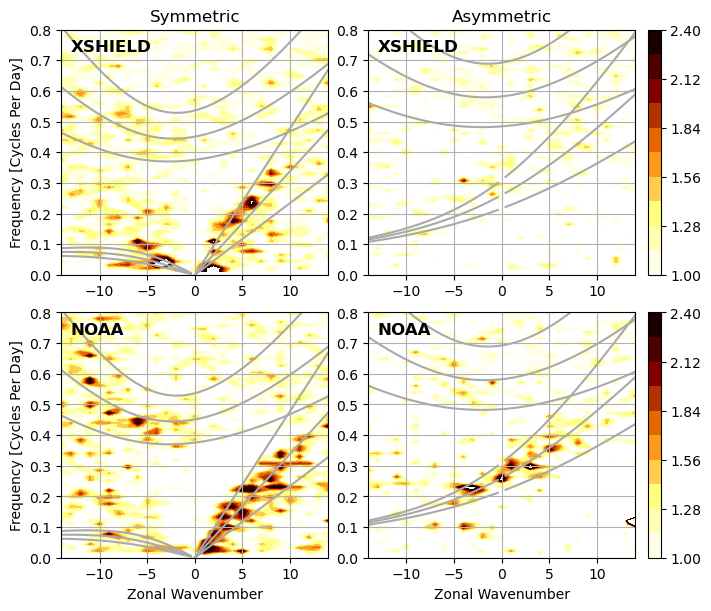

In [171]:
# plot spectrum
fig, axs = plt.subplots(2, 2, figsize=(7.0, 6), constrained_layout=True)

k = xshield_background.wavenumber
w = xshield_background.frequency
spectrum_levels = np.linspace(1.0, 2.4, 11)
diff_levels = np.linspace(-0.5, 0.5, 11)
c = 'darkgray' # COLOR FOR DISPERSION LINES/LABELS

axs[0, 0].set_title("Symmetric")
axs[0, 0].annotate(
    "XSHIELD",
    xy=(-13, 0.73),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="k",
)
for ii in range(3,6):
    axs[0, 0].plot(swk[ii, 0,:], swf[ii,0,:], color=c, linewidth=1.5)
    axs[0, 0].plot(swk[ii, 1,:], swf[ii,1,:], color=c, linewidth=1.5)
    axs[0, 0].plot(swk[ii, 2,:], swf[ii,2,:], color=c, linewidth=1.5)
    

axs[0, 1].set_title("Asymmetric")
axs[0, 1].annotate(
    "XSHIELD",
    xy=(-13, 0.73),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="k",
)
axs[0, 0].contourf(
    k, w, xshield_symmetric_peaks.values, levels=spectrum_levels, cmap="afmhot_r"
)
cs = axs[0, 1].contourf(
    k, w, xshield_asymmetric_peaks.values, levels=spectrum_levels, cmap="afmhot_r"
)
fig.colorbar(cs, ax=axs[0, 1])
for ii in range(0,3):
    axs[0, 1].plot(swk[ii, 0,:], swf[ii,0,:], color=c, linewidth=1.5)
    axs[0, 1].plot(swk[ii, 1,:], swf[ii,1,:], color=c, linewidth=1.5)
    axs[0, 1].plot(swk[ii, 2,:], swf[ii,2,:], color=c, linewidth=1.5)

axs[0, 0].set_ylabel("Frequency [Cycles Per Day]")

noaa_symmetric_peaks_plot = noaa_symmetric_peaks.values
noaa_symmetric_peaks_plot[noaa_symmetric_peaks_plot > spectrum_levels[-1]] = (
    spectrum_levels[-1]
)
axs[1, 0].contourf(
    k, w, noaa_symmetric_peaks_plot, levels=spectrum_levels, cmap="afmhot_r"
)
axs[1, 0].annotate(
    "NOAA",
    xy=(-13, 0.73),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="k",
)
for ii in range(3,6):
    axs[1, 0].plot(swk[ii, 0,:], swf[ii,0,:], color=c, linewidth=1.5)
    axs[1, 0].plot(swk[ii, 1,:], swf[ii,1,:], color=c, linewidth=1.5)
    axs[1, 0].plot(swk[ii, 2,:], swf[ii,2,:], color=c, linewidth=1.5)

cs = axs[1, 1].contourf(
    k, w, noaa_asymmetric_peaks.values, levels=spectrum_levels, cmap="afmhot_r"
)
axs[1, 1].annotate(
    "NOAA",
    xy=(-13, 0.73),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="k",
)
for ii in range(0,3):
    axs[1, 1].plot(swk[ii, 0,:], swf[ii,0,:], color=c, linewidth=1.5)
    axs[1, 1].plot(swk[ii, 1,:], swf[ii,1,:], color=c, linewidth=1.5)
    axs[1, 1].plot(swk[ii, 2,:], swf[ii,2,:], color=c, linewidth=1.5)
    
fig.colorbar(cs, ax=axs[1, 1])
axs[1, 0].set_ylabel("Frequency [Cycles Per Day]")

axs[1, 0].set_xlabel("Zonal Wavenumber")
axs[1, 1].set_xlabel("Zonal Wavenumber")

for i, ax in enumerate(axs.ravel()):
    ax.grid()
    ax.set_xlim(-14, 14)
    ax.set_ylim(0, 0.8)

Text(0.5, 0.98, 'Precip')

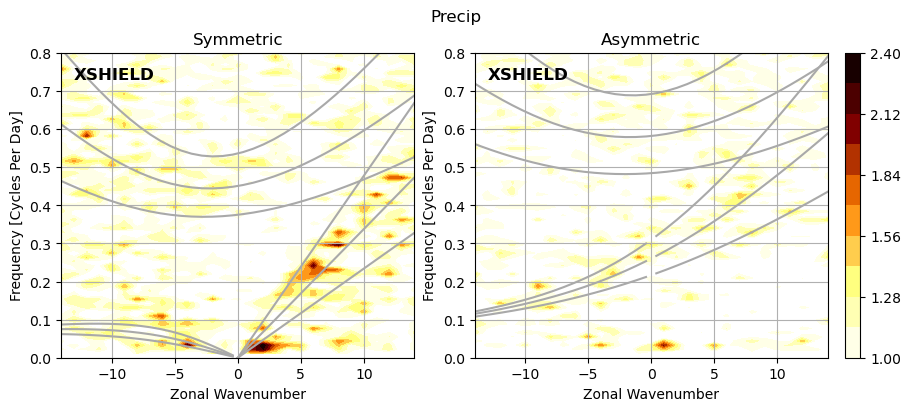

In [88]:
# plot spectrum
fig, axs = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)

k = xshield_pr_background.wavenumber
w = xshield_pr_background.frequency
spectrum_levels = np.linspace(1.0, 2.4, 11)
diff_levels = np.linspace(-0.5, 0.5, 11)
c = 'darkgray' # COLOR FOR DISPERSION LINES/LABELS

axs[0].set_title("Symmetric")
axs[0].annotate(
    "XSHIELD",
    xy=(-13, 0.73),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="k",
)
for ii in range(3,6):
    axs[0].plot(swk[ii, 0,:], swf[ii,0,:], color=c, linewidth=1.5)
    axs[0].plot(swk[ii, 1,:], swf[ii,1,:], color=c, linewidth=1.5)
    axs[0].plot(swk[ii, 2,:], swf[ii,2,:], color=c, linewidth=1.5)
    

axs[1].set_title("Asymmetric")
axs[1].annotate(
    "XSHIELD",
    xy=(-13, 0.73),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="k",
)
axs[0].contourf(
    k, w, xshield_pr_symmetric_peaks.values, levels=spectrum_levels, cmap="afmhot_r"
)
cs = axs[1].contourf(
    k, w, xshield_pr_asymmetric_peaks.values, levels=spectrum_levels, cmap="afmhot_r"
)
fig.colorbar(cs, ax=axs[1])
for ii in range(0,3):
    axs[1].plot(swk[ii, 0,:], swf[ii,0,:], color=c, linewidth=1.5)
    axs[1].plot(swk[ii, 1,:], swf[ii,1,:], color=c, linewidth=1.5)
    axs[1].plot(swk[ii, 2,:], swf[ii,2,:], color=c, linewidth=1.5)

axs[0].set_ylabel("Frequency [Cycles Per Day]")


axs[1].set_ylabel("Frequency [Cycles Per Day]")

axs[0].set_xlabel("Zonal Wavenumber")
axs[1].set_xlabel("Zonal Wavenumber")

for i, ax in enumerate(axs.ravel()):
    ax.grid()
    ax.set_xlim(-14, 14)
    ax.set_ylim(0, 0.8)
    
fig.suptitle('Precip')

Text(0.5, 0.98, 'v850')

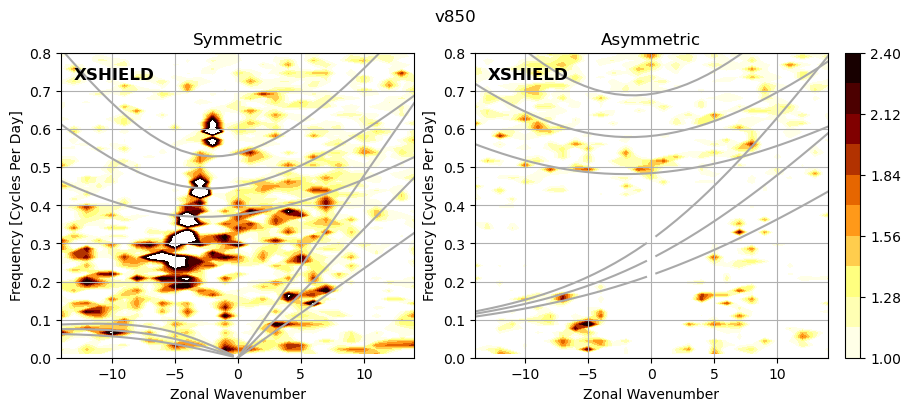

In [60]:
# plot spectrum
fig, axs = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)

k = xshield_u850_background.wavenumber
w = xshield_u850_background.frequency
spectrum_levels = np.linspace(1.0, 2.4, 11)
diff_levels = np.linspace(-0.5, 0.5, 11)
c = 'darkgray' # COLOR FOR DISPERSION LINES/LABELS

axs[0].set_title("Symmetric")
axs[0].annotate(
    "XSHIELD",
    xy=(-13, 0.73),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="k",
)
for ii in range(3,6):
    axs[0].plot(swk[ii, 0,:], swf[ii,0,:], color=c, linewidth=1.5)
    axs[0].plot(swk[ii, 1,:], swf[ii,1,:], color=c, linewidth=1.5)
    axs[0].plot(swk[ii, 2,:], swf[ii,2,:], color=c, linewidth=1.5)
    

axs[1].set_title("Asymmetric")
axs[1].annotate(
    "XSHIELD",
    xy=(-13, 0.73),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="k",
)
axs[0].contourf(
    k, w, xshield_u850_symmetric_peaks.values, levels=spectrum_levels, cmap="afmhot_r"
)
cs = axs[1].contourf(
    k, w, xshield_u850_asymmetric_peaks.values, levels=spectrum_levels, cmap="afmhot_r"
)
fig.colorbar(cs, ax=axs[1])
for ii in range(0,3):
    axs[1].plot(swk[ii, 0,:], swf[ii,0,:], color=c, linewidth=1.5)
    axs[1].plot(swk[ii, 1,:], swf[ii,1,:], color=c, linewidth=1.5)
    axs[1].plot(swk[ii, 2,:], swf[ii,2,:], color=c, linewidth=1.5)

axs[0].set_ylabel("Frequency [Cycles Per Day]")


axs[1].set_ylabel("Frequency [Cycles Per Day]")

axs[0].set_xlabel("Zonal Wavenumber")
axs[1].set_xlabel("Zonal Wavenumber")

for i, ax in enumerate(axs.ravel()):
    ax.grid()
    ax.set_xlim(-14, 14)
    ax.set_ylim(0, 0.8)
    
fig.suptitle('v850')

Text(0.5, 0.98, 'v250')

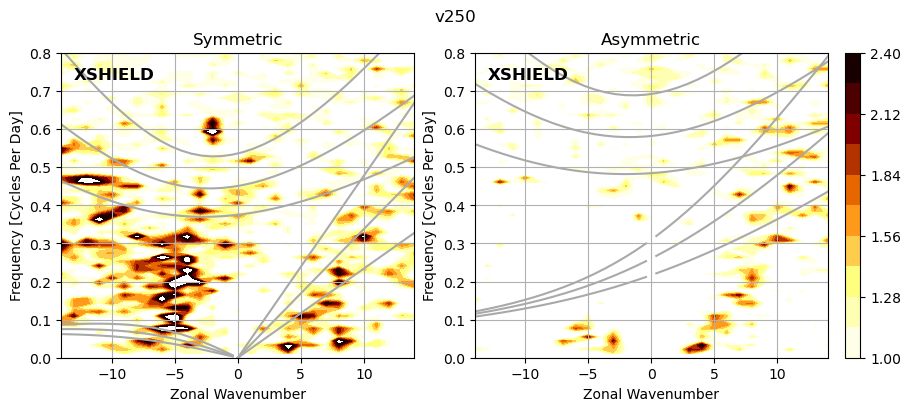

In [59]:
# plot spectrum
fig, axs = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)

k = xshield_u250_background.wavenumber
w = xshield_u250_background.frequency
spectrum_levels = np.linspace(1.0, 2.4, 11)
diff_levels = np.linspace(-0.5, 0.5, 11)
c = 'darkgray' # COLOR FOR DISPERSION LINES/LABELS

axs[0].set_title("Symmetric")
axs[0].annotate(
    "XSHIELD",
    xy=(-13, 0.73),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="k",
)
for ii in range(3,6):
    axs[0].plot(swk[ii, 0,:], swf[ii,0,:], color=c, linewidth=1.5)
    axs[0].plot(swk[ii, 1,:], swf[ii,1,:], color=c, linewidth=1.5)
    axs[0].plot(swk[ii, 2,:], swf[ii,2,:], color=c, linewidth=1.5)
    

axs[1].set_title("Asymmetric")
axs[1].annotate(
    "XSHIELD",
    xy=(-13, 0.73),
    xycoords="data",
    fontsize=12,
    fontweight="bold",
    color="k",
)
axs[0].contourf(
    k, w, xshield_u250_symmetric_peaks.values, levels=spectrum_levels, cmap="afmhot_r"
)
cs = axs[1].contourf(
    k, w, xshield_u250_asymmetric_peaks.values, levels=spectrum_levels, cmap="afmhot_r"
)
fig.colorbar(cs, ax=axs[1])
for ii in range(0,3):
    axs[1].plot(swk[ii, 0,:], swf[ii,0,:], color=c, linewidth=1.5)
    axs[1].plot(swk[ii, 1,:], swf[ii,1,:], color=c, linewidth=1.5)
    axs[1].plot(swk[ii, 2,:], swf[ii,2,:], color=c, linewidth=1.5)

axs[0].set_ylabel("Frequency [Cycles Per Day]")


axs[1].set_ylabel("Frequency [Cycles Per Day]")

axs[0].set_xlabel("Zonal Wavenumber")
axs[1].set_xlabel("Zonal Wavenumber")

for i, ax in enumerate(axs.ravel()):
    ax.grid()
    ax.set_xlim(-14, 14)
    ax.set_ylim(0, 0.8)
    
fig.suptitle('v250')

In [182]:
def plot_map(lat, lon, data, fig, ax, transform, **kwargs):
    cyclic_data, cyclic_lons = add_cyclic_point(data, coord=lon)
    cf = ax.contourf(
        cyclic_lons, lat, cyclic_data, transform=transform, **kwargs
    )
    fig.colorbar(cf, ax=ax, label="[$W/m^2$]")
    ax.coastlines()
    gridlines = ax.gridlines(
        crs=transform,
        draw_labels=True,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gridlines.top_labels = False
    gridlines.left_labels = True

Text(-174, 10, 'NOAA')

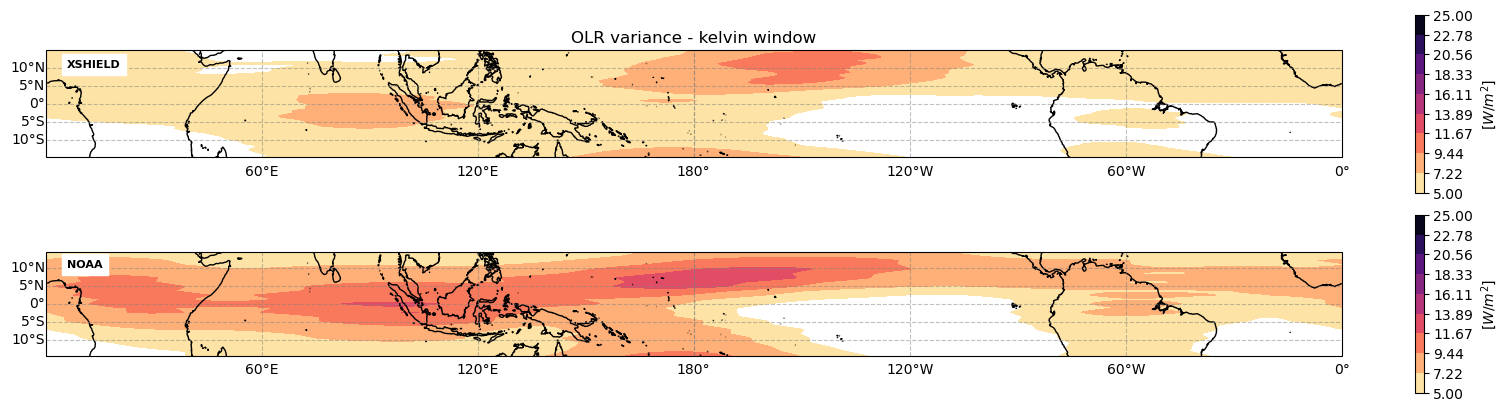

In [183]:
std_vmin = 5
std_vmax = 25
std_steps = 10
std_levels = np.linspace(std_vmin, std_vmax, std_steps)

window_name = "kelvin"  # mjo, kelvin, tropical_depression, inertio_gravity, mixed_rossby_gravity, equatorial_rossby
projection = ccrs.PlateCarree(central_longitude=-180)
transform = ccrs.PlateCarree()
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(15, 4),
    subplot_kw={"projection": projection},
    constrained_layout=True,
)
icon_array = filtered_xshield[window_name].std("time").values.T
noaa_array = filtered_noaa[window_name].std("time").values.T


title = f"OLR variance - {window_name} window"
plot_map(
    filtered_xshield.lat.values,
    filtered_xshield.lon.values,
    icon_array,
    fig,
    ax1,
    transform,
    levels=std_levels,
    cmap="magma_r",
)
ax1.annotate(
    "XSHIELD",
    xy=(-174, 10),
    xycoords="data",
    fontsize=8,
    fontweight="bold",
    backgroundcolor="w",
)
ax1.set_title(title)
plot_map(
    filtered_noaa.lat.values,
    filtered_noaa.lon.values,
    noaa_array,
    fig,
    ax2,
    transform,
    levels=std_levels,
    cmap="magma_r",
)
ax2.annotate(
    "NOAA",
    xy=(-174, 10),
    xycoords="data",
    fontsize=8,
    fontweight="bold",
    backgroundcolor="w",
)

# Hovmuller plots

In [89]:
filtered_xshield_anom = filter_variable(
    xshield_olr_anom, filters, grid_type="healpix", grid_dict=grid_dict
)

/home/sw5261/.conda/envs/easy25/lib/python3.12/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 17.56 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [90]:
xshield_olr_anom_trop = dataarray_healpix_to_equatorial_latlon(xshield_olr_anom, ds_xshield.crs.healpix_nside, 
                                                              ds_xshield.crs.healpix_order == "nest", 
                                                              minmax_lat=15)

/home/sw5261/.conda/envs/easy25/lib/python3.12/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 17.56 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [91]:
xshield_olr_anom_trop_avg = xshield_olr_anom_trop.mean(dim='lat')

In [92]:
xshield_filt_anom_tropics = filtered_xshield_anom.sel(lat=slice(-20,20)).mean(dim='lat')

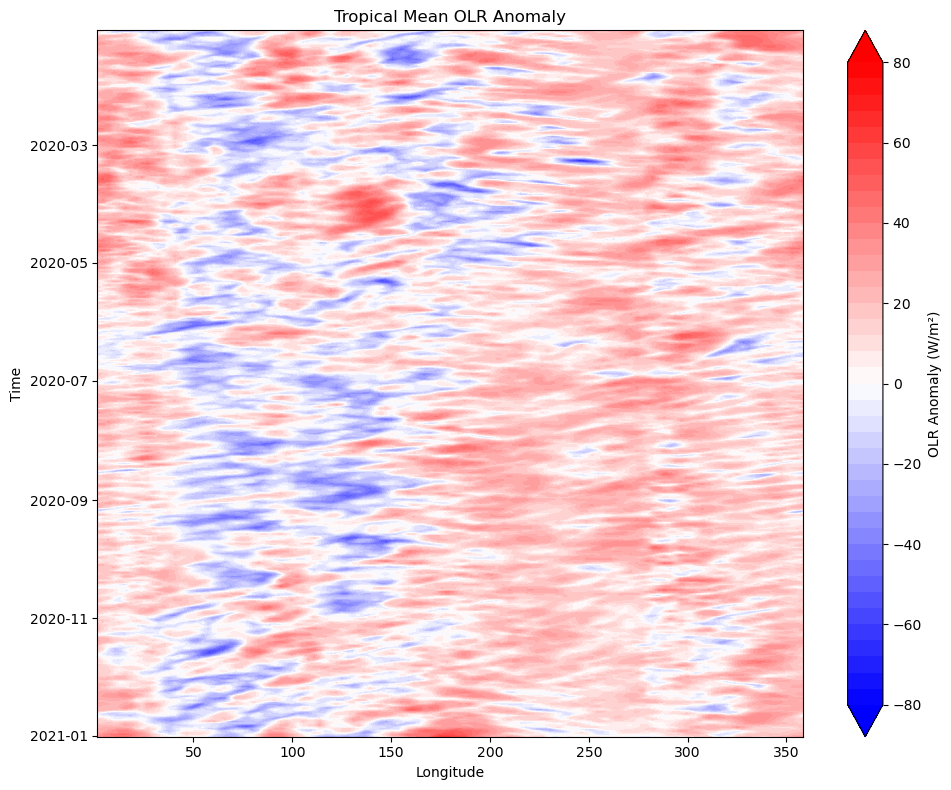

In [93]:
plt.figure(figsize=(10, 8))

# Contour plot
a = plt.contourf(
    xshield_olr_anom_trop_avg.lon,
    xshield_olr_anom_trop_avg.time,
    xshield_olr_anom_trop_avg,
    cmap=plt.cm.bwr,
    extend='both',
    levels=np.arange(-80, 81, 4)
)

# Invert time axis (if desired)
plt.gca().invert_yaxis()

# Colorbar
cbar = plt.colorbar(a)
cbar.set_label("OLR Anomaly (W/m²)")

# Axis labels
plt.xlabel("Longitude")
plt.ylabel("Time")

# Optional: add a title
plt.title("Tropical Mean OLR Anomaly")

# Improve layout
plt.tight_layout()
plt.show()

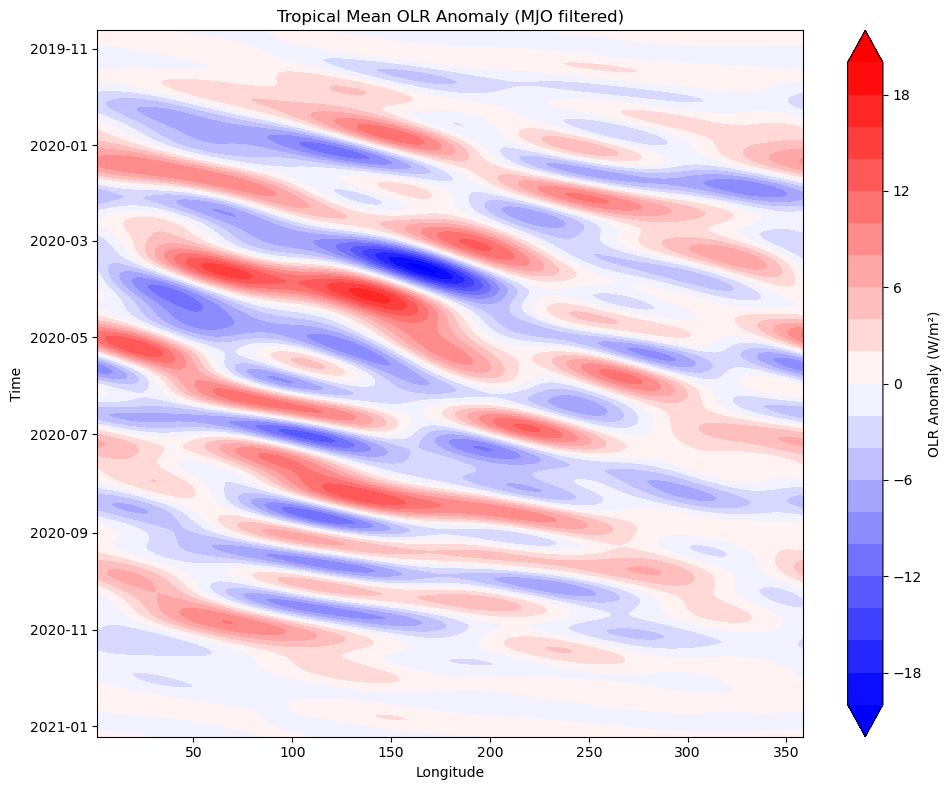

In [130]:
plt.figure(figsize=(10, 8))

# Contour plot
a = plt.contourf(
    xshield_filt_anom_tropics.lon,
    xshield_filt_anom_tropics.time,
    xshield_filt_anom_tropics.mjo,
    cmap=plt.cm.bwr,
    extend='both',
    levels=np.arange(-20, 21, 2)
)

# Invert time axis (if desired)
plt.gca().invert_yaxis()

# Colorbar
cbar = plt.colorbar(a)
cbar.set_label("OLR Anomaly (W/m²)")

# Axis labels
plt.xlabel("Longitude")
plt.ylabel("Time")

# Optional: add a title
plt.title("Tropical Mean OLR Anomaly (MJO filtered)")

# Improve layout
plt.tight_layout()
plt.show()

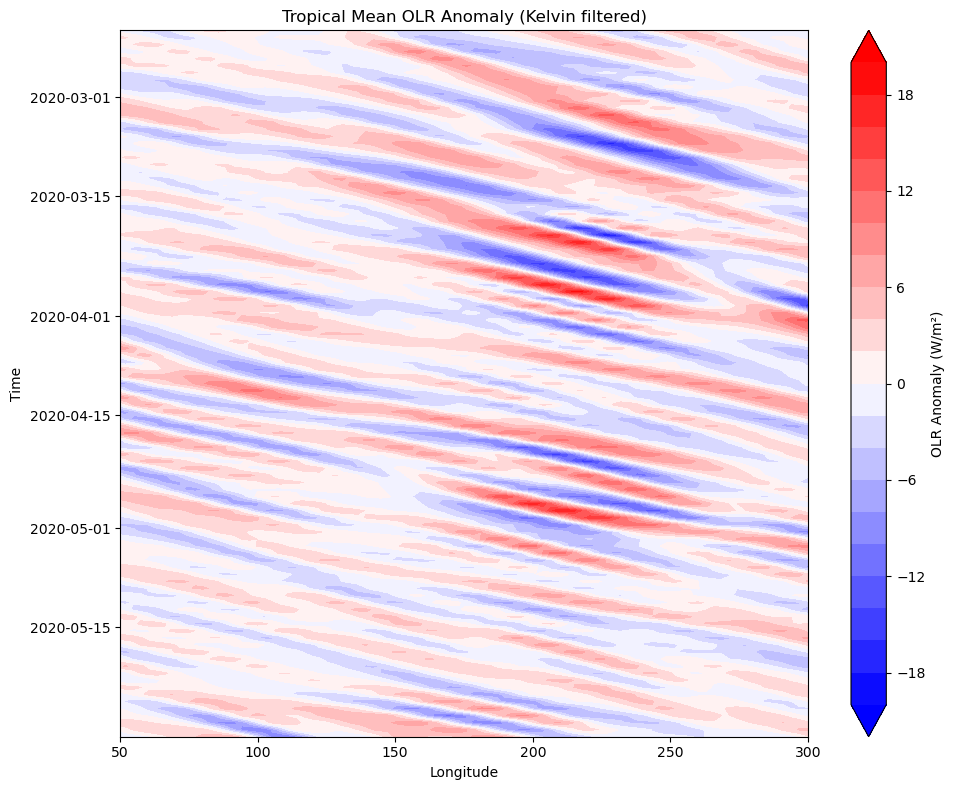

In [99]:
plt.figure(figsize=(10, 8))

# Contour plot
a = plt.contourf(
    xshield_filt_anom_tropics.lon,
    xshield_filt_anom_tropics.time,
    xshield_filt_anom_tropics.kelvin,
    cmap=plt.cm.bwr,
    extend='both',
    levels=np.arange(-20, 21, 2)
)

# Colorbar
cbar = plt.colorbar(a)
cbar.set_label("OLR Anomaly (W/m²)")

plt.xlim([50,300])
plt.ylim([xshield_filt_anom_tropics.time[50],xshield_filt_anom_tropics.time[150]])

# Axis labels
plt.xlabel("Longitude")
plt.ylabel("Time")
# Invert time axis (if desired)
plt.gca().invert_yaxis()

# Optional: add a title
plt.title("Tropical Mean OLR Anomaly (Kelvin filtered)")

# Improve layout
plt.tight_layout()
plt.show()

# Lagged composites

In [110]:
from scipy.stats import linregress

In [ ]:
# Kelvin wave high variance at 150 W / 210 E
# MJO high variance at 120 E

In [111]:
# Define regression function
def linregress_func(y, x):
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan, np.nan  # Not enough data points
    slope, intercept, r_value, p_value, std_err = linregress(x[mask], y[mask])
    return slope, r_value

In [158]:
filtered_xshield = filter_variable(
    xshield_olr, filters, grid_type="healpix", grid_dict=grid_dict
)

In [222]:
basepoint_lat = 7
basepoint_lon = 180

In [223]:
time_series_base = filtered_xshield.kelvin.sel(lat=basepoint_lat, lon=basepoint_lon,method='nearest')

In [224]:
xshield_olr_latlon = dataarray_healpix_to_equatorial_latlon(xshield_olr, ds_xshield.crs.healpix_nside, 
                                                              ds_xshield.crs.healpix_order == "nest", 
                                                              minmax_lat=25)

In [347]:
xshield_u850_latlon = dataarray_healpix_to_equatorial_latlon(xshield_u850, ds_xshield.crs.healpix_nside, 
                                                              ds_xshield.crs.healpix_order == "nest", 
                                                              minmax_lat=25)

In [348]:
xshield_v850_latlon = dataarray_healpix_to_equatorial_latlon(xshield_v850, ds_xshield.crs.healpix_nside, 
                                                              ds_xshield.crs.healpix_order == "nest", 
                                                              minmax_lat=25)

In [349]:
xshield_gz_latlon = dataarray_healpix_to_equatorial_latlon(xshield_gz, ds_xshield.crs.healpix_nside, 
                                                              ds_xshield.crs.healpix_order == "nest", 
                                                              minmax_lat=25)

In [225]:
# Apply the regression to each gridpoint
slope_olr, r = xr.apply_ufunc(
    linregress_func,
    xshield_olr_latlon.isel(time=slice(30,-30)),
    time_series_base.isel(time=slice(30,-30)),
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[[], []],
    vectorize=True,
    dask="parallelized",  # If using dask-backed data
    output_dtypes=[float, float],
)

In [350]:
# Apply the regression to each gridpoint
slope_u850, r = xr.apply_ufunc(
    linregress_func,
    xshield_u850_latlon.isel(time=slice(30,-30)),
    time_series_base.isel(time=slice(30,-30)),
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[[], []],
    vectorize=True,
    dask="parallelized",  # If using dask-backed data
    output_dtypes=[float, float],
)
# Apply the regression to each gridpoint
slope_v850, r = xr.apply_ufunc(
    linregress_func,
    xshield_v850_latlon.isel(time=slice(30,-30)),
    time_series_base.isel(time=slice(30,-30)),
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[[], []],
    vectorize=True,
    dask="parallelized",  # If using dask-backed data
    output_dtypes=[float, float],
)


In [351]:
# Apply the regression to each gridpoint
slope_gz, r = xr.apply_ufunc(
    linregress_func,
    xshield_gz_latlon.isel(time=slice(30,-30)),
    time_series_base.isel(time=slice(30,-30)),
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[[], []],
    vectorize=True,
    dask="parallelized",  # If using dask-backed data
    output_dtypes=[float, float],
)

In [226]:
def plot_map_regress(lat, lon, data, fig, ax, transform, **kwargs):
    cyclic_data, cyclic_lons = add_cyclic_point(data, coord=lon)
    cf = ax.contourf(
        cyclic_lons, lat, cyclic_data, transform=transform, **kwargs
    )
    fig.colorbar(cf, ax=ax, label="[$W/m^2$]")
    ax.coastlines()
    gridlines = ax.gridlines(
        crs=transform,
        draw_labels=True,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gridlines.top_labels = False
    gridlines.left_labels = True

Text(0.5, 1.0, 'kelvin Lag +0')

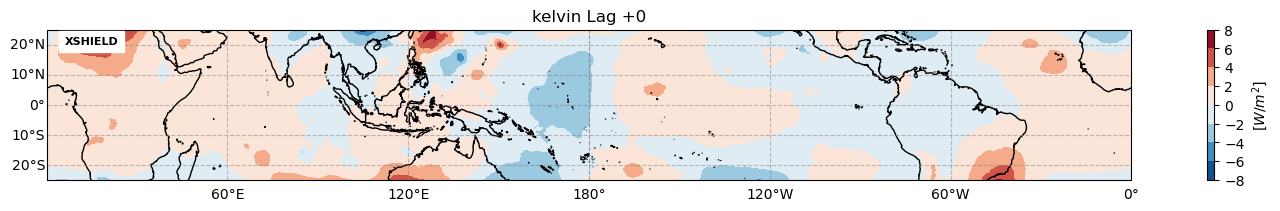

In [255]:
window_name = "kelvin"  # mjo, kelvin, tropical_depression, inertio_gravity, mixed_rossby_gravity, equatorial_rossby
projection = ccrs.PlateCarree(central_longitude=-180)
transform = ccrs.PlateCarree()

slope_max = np.max(np.abs(slope_olr))
slope_levels = np.arange(-slope_max,slope_max+slope_max/10,slope_max/10)
fig, ax = plt.subplots(
    1,
    1,
    figsize=(15, 2),
    subplot_kw={"projection": projection},
    constrained_layout=True,
)

title = f"{window_name} Lag +0"
plot_map_regress(
    slope_olr.lat.values,
    slope_olr.lon.values,
    slope_gz.T*20,
    fig,
    ax,
    transform,
    #levels=slope_levels,
    cmap="RdBu_r",
)
ax.annotate(
    "XSHIELD",
    xy=(-174, 20),
    xycoords="data",
    fontsize=8,
    fontweight="bold",
    backgroundcolor="w",
)
ax.set_title(title)

In [342]:
def plot_map_regress_wind(lat, lon, data1, data2, fig, ax, transform, u_wind=None, v_wind=None, wind_skip=5, **kwargs):
    
    
    # Add cyclic point for contour data
    cyclic_data1, cyclic_lons = add_cyclic_point(data1, coord=lon)
    cyclic_data2, cyclic_lons = add_cyclic_point(data2, coord=lon)

    # Plot filled contours (Tb)
    cf = ax.contourf(
        cyclic_lons, lat, cyclic_data1, transform=transform, **kwargs
    )
    # Plot lines  (OLR)
    cg = ax.contour(
        cyclic_lons, lat, cyclic_data2, transform=transform, colors='tab:red',levels=15
    )
    fig.colorbar(cf, ax=ax, label="[$W/m^2$]")

    # Add coastlines and gridlines
    ax.coastlines()
    gridlines = ax.gridlines(
        crs=transform,
        draw_labels=True,
        color="grey",
        alpha=0.5,
        linestyle="--",
    )
    gridlines.top_labels = False
    gridlines.left_labels = True

    # Plot wind vectors if provided
    if u_wind is not None and v_wind is not None:
        # Add cyclic point to wind components
        u_cyclic, _ = add_cyclic_point(u_wind, coord=lon)
        v_cyclic, _ = add_cyclic_point(v_wind, coord=lon)

        # Create meshgrid for quiver
        lon2d, lat2d = np.meshgrid(cyclic_lons, lat)

        # Skip vectors to reduce clutter
        ax.quiver(
            lon2d[::wind_skip, ::wind_skip],
            lat2d[::wind_skip, ::wind_skip],
            u_cyclic[::wind_skip, ::wind_skip],
            v_cyclic[::wind_skip, ::wind_skip],
            transform=transform,
            scale=40,
            width=0.002,
        )
        
    ax.set_xlim([100-180, 280-180])
        
    

Text(0.5, 1.0, 'Kelvin 250hPa Lag +0')

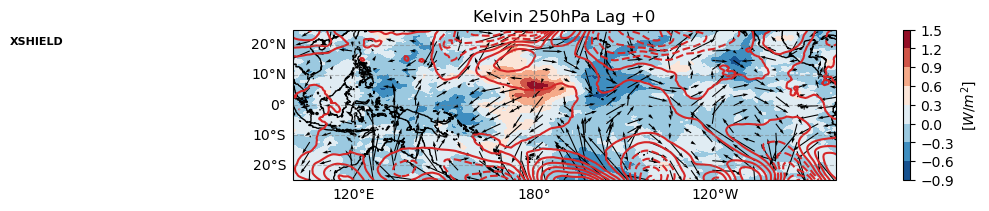

In [353]:
window_name = "Kelvin 250hPa"  # mjo, kelvin, tropical_depression, inertio_gravity, mixed_rossby_gravity, equatorial_rossby
projection = ccrs.PlateCarree(central_longitude=-180)
transform = ccrs.PlateCarree()

#slope_max = np.max(np.abs(slope_olr))
#slope_levels = np.arange(-slope_max,slope_max+slope_max/10,slope_max/10)
fig, ax = plt.subplots(
    1,
    1,
    figsize=(15, 2),
    subplot_kw={"projection": projection},
    constrained_layout=True,
)

title = f"{window_name} Lag +0"
plot_map_regress_wind(
    slope_olr.lat.values,
    slope_olr.lon.values,
    slope_olr.T,
    slope_gz.T*-20,
    fig,
    ax,
    transform,
    slope_u850.T*-20,
    slope_v850.T*-20,
    10,
    #levels=slope_levels,
    cmap="RdBu_r",
)

ax.annotate(
    "XSHIELD",
    xy=(-174, 20),
    xycoords="data",
    fontsize=8,
    fontweight="bold",
    backgroundcolor="w",
)
ax.set_title(title)